<a href="https://colab.research.google.com/github/zwimpee/cursivetransformer/blob/main/visualize_attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !sudo apt update
# !sudo apt install libcairo2-dev ffmpeg \
#     texlive texlive-latex-extra texlive-fonts-extra \
#     texlive-latex-recommended texlive-science \
#     tipa libpango1.0-dev
# !pip install manim
# !pip install IPython==8.21.0

In [2]:
# Clone the cursivetransformer repository and install its requirements
!rm -rf cursivetransformer && git clone https://github.com/zwimpee/cursivetransformer.git
!cd cursivetransformer && pip install -r requirements.txt
!wandb login

Cloning into 'cursivetransformer'...
remote: Enumerating objects: 3119, done.
remote: Counting objects: 100% (733/733), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 3119 (delta 636), reused 650 (delta 571), pack-reused 2386 (from 1)
Receiving objects: 100% (3119/3119), 72.17 MiB | 14.81 MiB/s, done.
Resolving deltas: 100% (1750/1750), done.
  Cloning https://github.com/callummcdougall/CircuitsVis.git to /tmp/pip-req-build-3v92jd4x
  Running command git clone --filter=blob:none --quiet https://github.com/callummcdougall/CircuitsVis.git /tmp/pip-req-build-3v92jd4x
  Resolved https://github.com/callummcdougall/CircuitsVis.git to commit 1e6129d08cae7af9242d9ab5d3ed322dd44b4dd3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.7/472.7 kB 34.6 MB/s eta 0:00

In [8]:
import sys
sys.path.append('/content/cursivetransformer/')

import colorsys
import numpy as np
import torch
from torch.nn import functional as F
import math
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

from cursivetransformer.model import get_all_args, get_checkpoint
from cursivetransformer.data import create_datasets, offsets_to_strokes, word_offsets_to_points
from cursivetransformer.sample import generate_n_words, plot_strokes, offsets_to_strokes

In [4]:
args = get_all_args(False)
args.wandb_project = 'bigbank_2k'
args.load_from_run_id = 'ff2kly3t'
args.max_seq_length = 1250
torch.manual_seed(args.seed)
torch.cuda.manual_seed_all(args.seed)
train_dataset, test_dataset = create_datasets(args)
args.block_size = train_dataset.get_stroke_seq_length()
args.context_block_size = train_dataset.get_text_seq_length()
args.vocab_size = train_dataset.get_vocab_size()
args.context_vocab_size = train_dataset.get_char_vocab_size()
print(f"Dataset determined that: {args.vocab_size=}, {args.block_size=}")
model, _, _, _, _ = get_checkpoint(args, sample_only=True)

Enter your W&B API key: ··········
Trying to load dataset file from /content/cursivetransformer/data/bigbank.json.zip
Succeeded in loading the bigbank dataset; contains 2000 items.
For a dataset of 1900 examples we can generate 205257574037880 combinations of 5 examples.
Generating 497000 random combinations.
For a dataset of 100 examples we can generate 75287520 combinations of 5 examples.
Generating 3000 random combinations.
Number of examples in the train dataset: 497000
Number of examples in the test dataset: 3000
Average number of words per example: 5.0
Max token sequence length: 1250
Number of unique characters in the ascii vocabulary: 71
Ascii vocabulary:
	" enaitoshrdx.vpukbgfcymzw1lqj804I92637OTAS5N)EHR"'(BCQLMWYU,ZF!DXV?KPGJ"
Split up the dataset into 497000 training examples and 3000 test examples
Dataset determined that: args.vocab_size=455, args.block_size=1250
Number of Transformer parameters: 384064
Model #params: 413184
Finding latest checkpoint for W&B run id ff2kly3t


wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb:   1 of 1 files downloaded.  


In [9]:
def visualize_attention_patterns(self_attn, cross_attn, layer_title, num_heads_to_plot=4):
    # Get dimensions
    seq_len = self_attn.shape[1]
    context_len = cross_attn.shape[2]

    # Set up the plot
    fig, axes = plt.subplots(2, num_heads_to_plot, figsize=(20, 10))
    fig.suptitle(layer_title, fontsize=16)

    # Plot self-attention patterns
    for i in range(num_heads_to_plot):
        sns.heatmap(self_attn[i], ax=axes[0, i], cmap="YlGnBu", cbar=False)
        axes[0, i].set_title(f"Self-Attention Head {i+1}")
        axes[0, i].set_xlabel("Token Position")
        axes[0, i].set_ylabel("Token Position")

        # Set x and y ticks to show only every 100th position
        tick_locations = np.arange(0, seq_len, 100)
        axes[0, i].set_xticks(tick_locations)
        axes[0, i].set_yticks(tick_locations)
        axes[0, i].set_xticklabels(tick_locations)
        axes[0, i].set_yticklabels(tick_locations)

    # Plot cross-attention patterns
    for i in range(num_heads_to_plot):
        sns.heatmap(cross_attn[i], ax=axes[1, i], cmap="YlGnBu", cbar=False)
        axes[1, i].set_title(f"Cross-Attention Head {i+1}")
        axes[1, i].set_xlabel("Context Position")
        axes[1, i].set_ylabel("Token Position")

        # Set x ticks to show only every 5th position for context
        x_tick_locations = np.arange(0, context_len, 5)
        axes[1, i].set_xticks(x_tick_locations)
        axes[1, i].set_xticklabels(x_tick_locations)

        # Set y ticks to show only every 100th position for tokens
        y_tick_locations = np.arange(0, seq_len, 100)
        axes[1, i].set_yticks(y_tick_locations)
        axes[1, i].set_yticklabels(y_tick_locations)

    plt.tight_layout()
    plt.show()

In [10]:
self_attn_patterns = {i: {} for i in range(len(model.transformer.h))}
cross_attn_patterns = {i: {} for i in range(len(model.transformer.h))}

def self_attn_hook(mod, inp, out):
    # The attention pattern is computed but not directly returned
    # We need to recompute it here
    q, k, v = mod.c_attn(inp[0]).split(mod.n_embd, dim=2)
    B, T, C = q.size()
    k = k.view(B, T, mod.n_head, C // mod.n_head).transpose(1, 2)
    q = q.view(B, T, mod.n_head, C // mod.n_head).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(mod.bias[:,:,:T,:T] == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    layer_idx = next(i for i, layer in enumerate(model.transformer.h) if layer.attn == mod)
    self_attn_patterns[layer_idx][mod] = att.detach()

def cross_attn_hook(mod, inp, out):
    # The attention pattern is computed but not directly returned
    # We need to recompute it here
    x, context = inp
    B, T, C = x.size()
    _, T_ctx, _ = context.size()
    q = mod.c_attn_q(x).view(B, T, mod.n_ctx_head, C // mod.n_ctx_head).transpose(1, 2)
    k, v = mod.c_attn_kv(context).split(mod.n_embd_context, dim=2)
    k = k.view(B, T_ctx, mod.n_ctx_head, C // mod.n_ctx_head).transpose(1, 2)
    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = F.softmax(att, dim=-1)
    layer_idx = next(i for i, layer in enumerate(model.transformer.h) if layer.cross_attn == mod)
    cross_attn_patterns[layer_idx][mod] = att.detach()

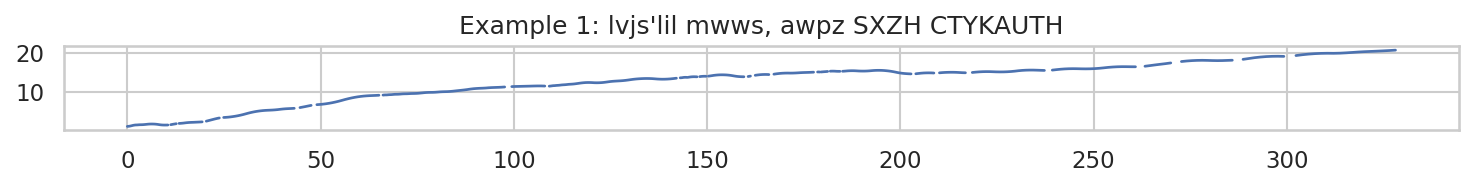

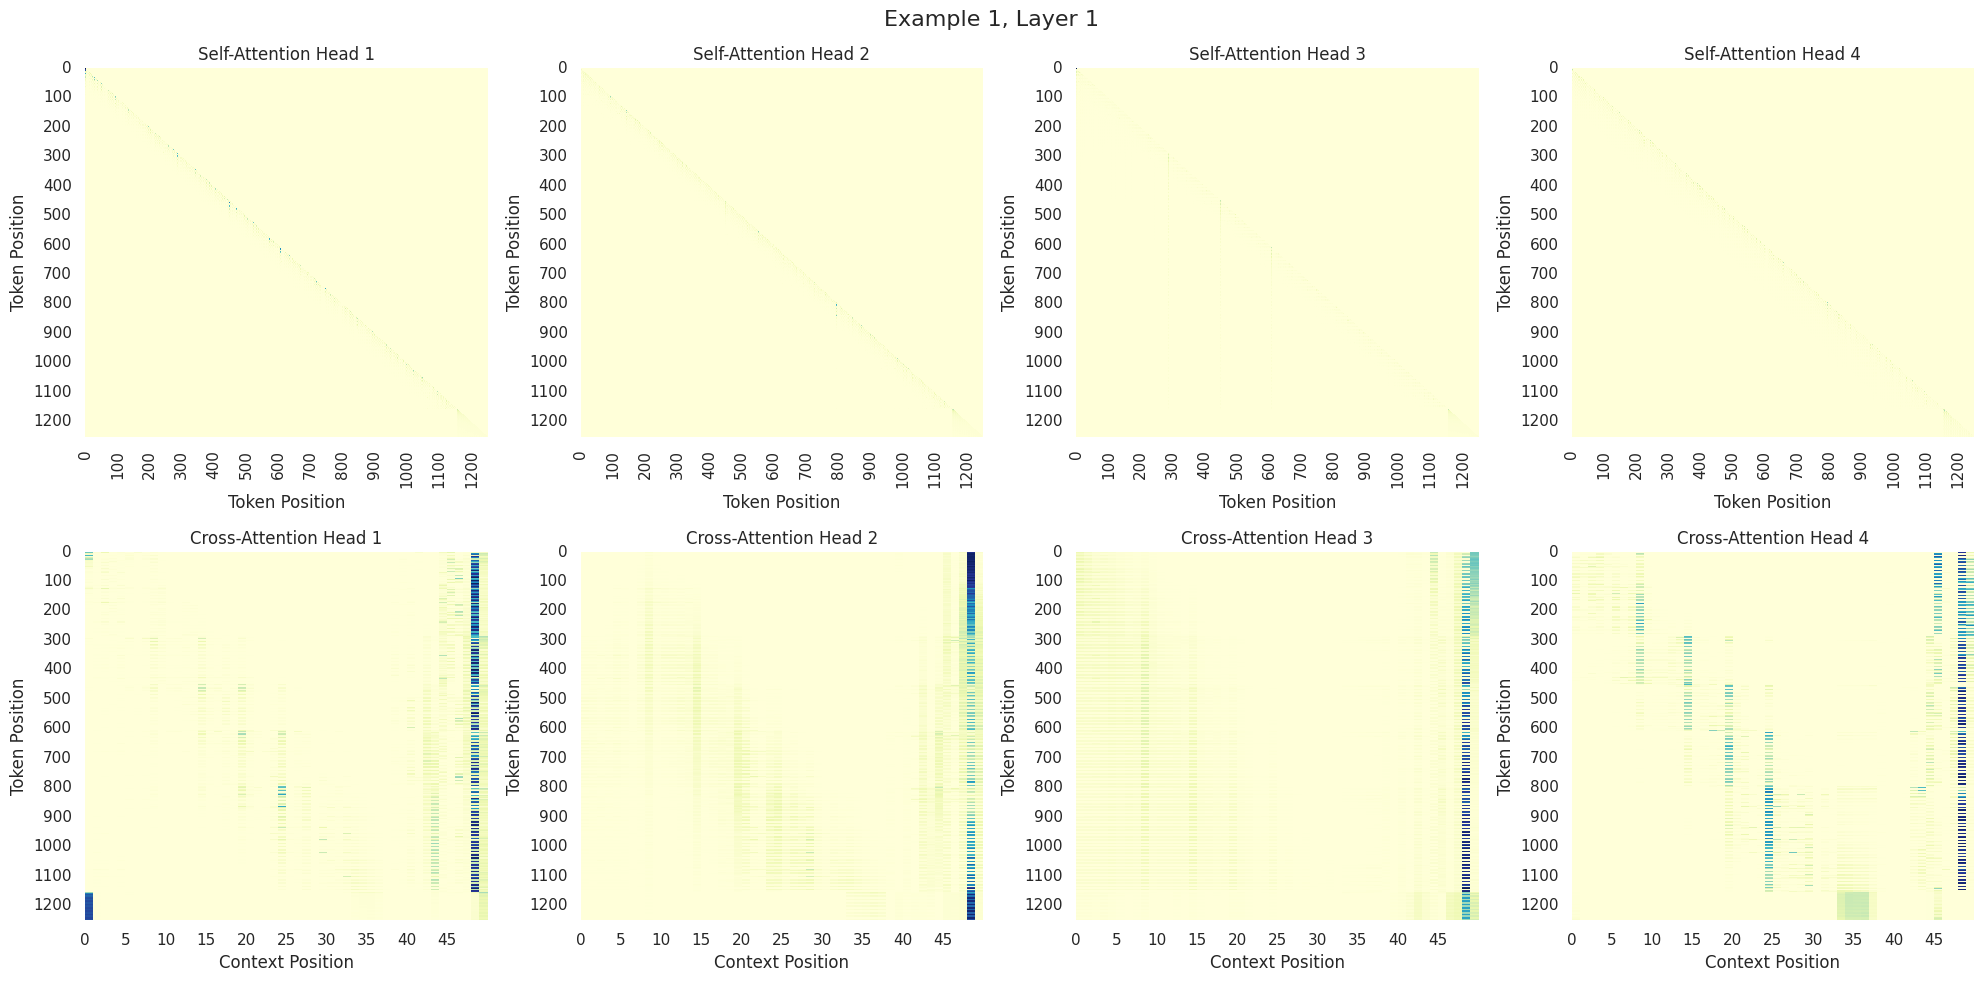

KeyboardInterrupt: 

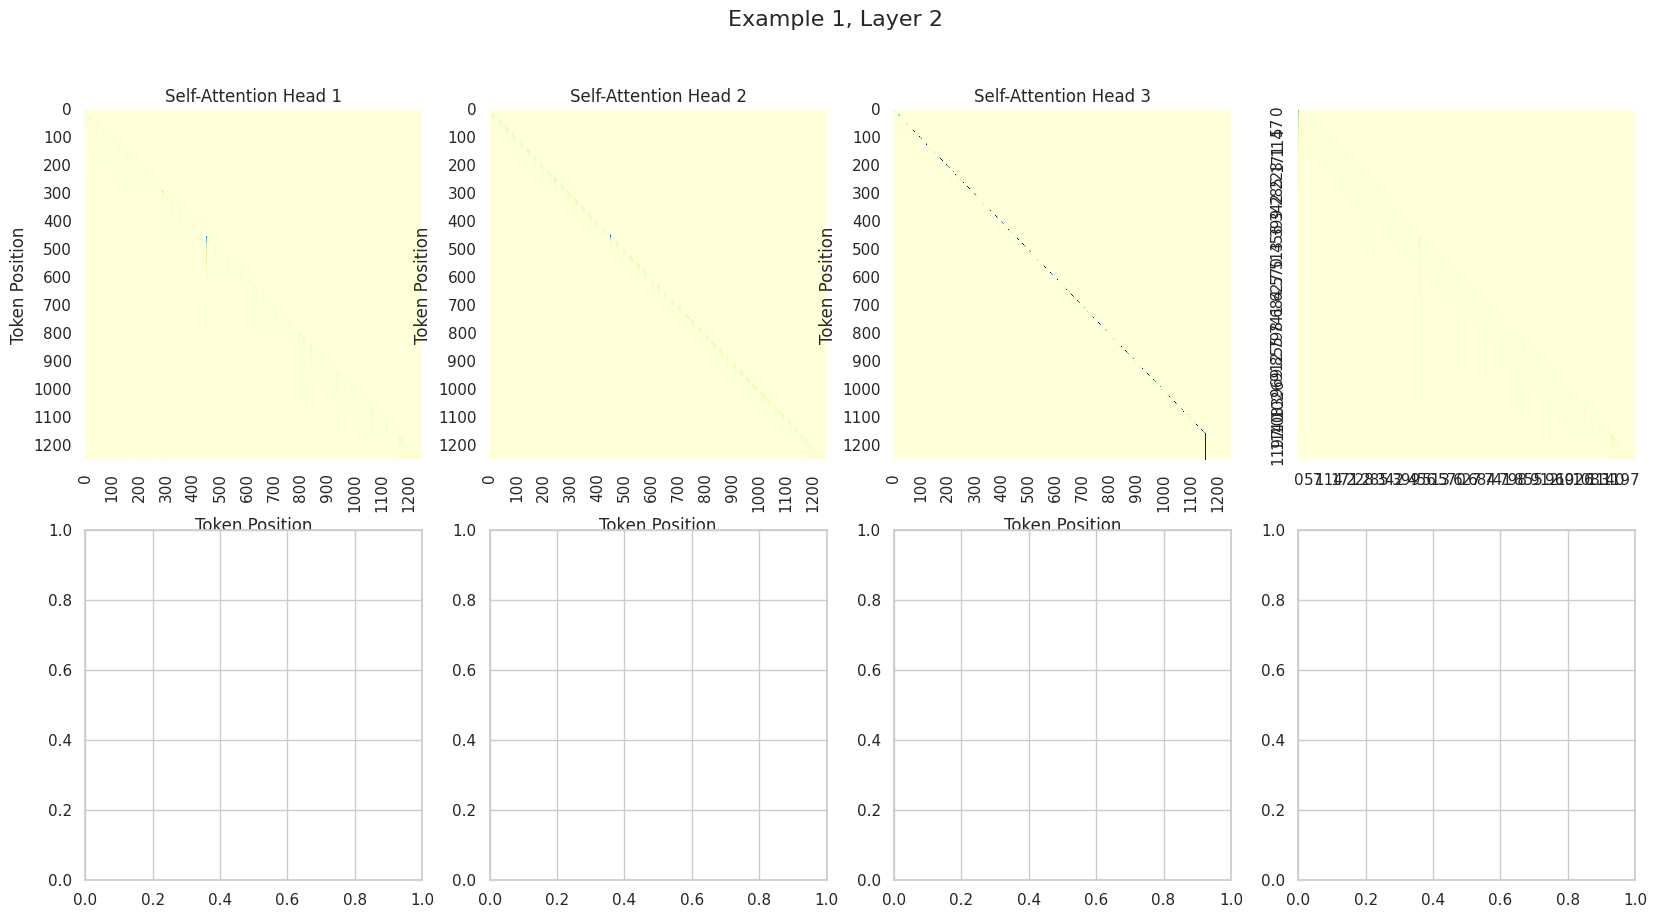

In [11]:
def plot_attention(model, dataset, num_examples=1):
    hooks = []
    for layer in model.transformer.h:
        self_hook = layer.attn.register_forward_hook(self_attn_hook)
        cross_hook = layer.cross_attn.register_forward_hook(cross_attn_hook)
        hooks.extend([self_hook, cross_hook])

    try:
        for i in range(num_examples):
            x, c, y = dataset[i]
            x = x.unsqueeze(0).to('cuda')
            c = c.unsqueeze(0).to('cuda')
            y = y.unsqueeze(0).to('cuda')

            with torch.no_grad():
                output = model(x, c)

            # Decode x into offsets using the dataset's decode_stroke method
            decoded_offsets = dataset.decode_stroke(x.squeeze().cpu())

            # Handle the new word-level encoding
            all_strokes = []
            for word_offsets in decoded_offsets:
                word_strokes = offsets_to_strokes(np.array(word_offsets))
                all_strokes.append(word_strokes)

            # Combine all strokes with appropriate spacing
            combined_strokes = word_offsets_to_points(all_strokes)

            # Decode ASCII tokens into string characters
            ascii_text = dataset.decode_text(c.squeeze().cpu())

            # Plot the combined strokes for this example
            plot_strokes(combined_strokes, f"Example {i+1}: {ascii_text}")

            # Visualize attention patterns for each layer
            for layer_idx in range(len(model.transformer.h)):
                self_attn = next(iter(self_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()
                cross_attn = next(iter(cross_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()

                visualize_attention_patterns(self_attn, cross_attn, f"Example {i+1}, Layer {layer_idx+1}")
    finally:
        for hook in hooks:
            hook.remove()

plot_attention(model, test_dataset)

In [ ]:
def get_examples(model, dataset, num_examples=1):
    hooks = []
    for layer in model.transformer.h:
        self_hook = layer.attn.register_forward_hook(self_attn_hook)
        cross_hook = layer.cross_attn.register_forward_hook(cross_attn_hook)
        hooks.extend([self_hook, cross_hook])
    examples = []
    for i in range(num_examples):
        x, c, y = dataset[i]
        x = x.unsqueeze(0).to('cuda')
        c = c.unsqueeze(0).to('cuda')
        y = y.unsqueeze(0).to('cuda')

        with torch.no_grad():
            output = model(x, c)

        # Decode x into offsets using the dataset's decode_stroke method
        decoded_offsets = dataset.decode_stroke(x.squeeze().cpu())
        strokes = offsets_to_strokes(decoded_offsets)

        # Decode ASCII tokens into string characters
        ascii_text = dataset.decode_text(c.squeeze().cpu())

        # Get attention patterns
        _self_attn_patterns = []
        _cross_attn_patterns = []
        for layer_idx in range(len(model.transformer.h)):
            self_attn = next(iter(self_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()
            cross_attn = next(iter(cross_attn_patterns[layer_idx].values())).squeeze(0).cpu().numpy()

            _self_attn_patterns.append(self_attn)
            _cross_attn_patterns.append(cross_attn)

        # Stack attention patterns across layers
        self_attn_all_layers = np.stack(_self_attn_patterns)
        cross_attn_all_layers = np.stack(_cross_attn_patterns)

        # Prepare the example data
        example = {
            'stroke_points': strokes,
            'ascii_sequence': ascii_text,
            'self_attention': self_attn_all_layers,
            'cross_attention': cross_attn_all_layers
        }

        examples.append(example)

    for hook in hooks:
        hook.remove()

    return examples

In [ ]:
examples = get_examples(model, test_dataset)

In [ ]:
points = examples[0]['stroke_points']
ascii_sequence = examples[0]['ascii_sequence']
_ = plot_strokes(points, title=ascii_sequence)

In [ ]:
from manim import *

In [ ]:
%%manim -qm -v WARNING PlotStrokesAnimation

class PlotStrokesAnimation(Scene):
    def construct(self):
        # Title
        title = Text("Plotting Handwritten Example", font_size=36)
        title.to_edge(UP)
        self.play(Write(title))
        self.wait(1)

        # Convert stroke data into Manim mobjects
        strokes = self.create_strokes(points)

        # # Display the strokes
        # self.play(Create(strokes, run_time=5))
        # self.wait(2)

        # Add label for the ASCII sequence
        label = Text(f"ASCII Sequence: {ascii_sequence}", font_size=24)
        label.next_to(strokes, DOWN)
        self.play(Write(label))
        self.wait(3)

        # - [ ] TODO,DEBUG: Display the strokes AFTER the ascii sequence
        self.play(Create(strokes, run_time=5))
        self.wait(2)

    def create_strokes(self, points):
        # Initialize variables
        stroke_paths = VGroup()
        path_points = []  # List to hold points for the current path

        # Iterate through the points
        for i in range(len(points)):
            x, y, p = points[i]
            # Invert the y-coordinate
            y = -y
            point = np.array([x, y, 0])

            if p == 1:
                # Pen down, collect points
                path_points.append(point)
            else:
                # Pen up, create a path if there are collected points
                if path_points:
                    current_path = VMobject()
                    current_path.set_points_as_corners(path_points)
                    stroke_paths.add(current_path)
                    path_points = []  # Reset for the next path

        # Add the last path if any points remain
        if path_points:
            current_path = VMobject()
            current_path.set_points_as_corners(path_points)
            stroke_paths.add(current_path)

        # Style the strokes
        stroke_paths.set_stroke(color=BLUE, width=2)
        stroke_paths.move_to(ORIGIN)

        # Scale strokes to fit the scene
        stroke_paths.scale(2)

        return stroke_paths

In [ ]:
%%manim -qm -v WARNING AttentionVisualizationAnimation

class AttentionVisualizationAnimation(Scene):
    def construct(self):
        # Title
        title = Text("Attention Visualization", font_size=36)
        title.to_edge(UP)
        self.play(Write(title))
        self.wait(1)

        for example in examples[:1]:
            stroke_points = example['stroke_points']
            ascii_sequence = example['ascii_sequence']
            self_attention = example['self_attention']

            # Create the axes
            axes = Axes(
                x_range=[0, 1, 0.2],
                y_range=[0, 1, 0.2],
                x_length=6,
                y_length=6,
                axis_config={"include_tip": False},
            )
            axes.to_edge(DOWN)
            self.play(Create(axes))

            # Display ASCII sequence
            ascii_text = Text(ascii_sequence, font_size=24)
            ascii_text.next_to(title, DOWN)
            self.play(Write(ascii_text))

            # Animate the drawing of strokes
            path = VMobject()
            for i, (x, y, p) in enumerate(stroke_points):
                new_point = axes.c2p(x, y)

                if p == 1 or path.get_num_points() == 0:  # Pen down or start of a new path
                    if path.get_num_points() > 0:
                        self.play(Create(path), run_time=0.05)
                    path = VMobject()
                    path.start_new_path(new_point)
                else:  # Continue the current path
                    path.add_line_to(new_point)

                # Color the path based on attention
                attention_score = np.mean(self_attention[:, :, i, 0])  # Average across layers and heads
                color = self.attention_to_color(attention_score)
                path.set_stroke(color=color, width=2)

                if i == len(stroke_points) - 1:  # Last point
                    self.play(Create(path), run_time=0.05)

            self.wait(1)

            # Clear the scene for the next example
            self.play(FadeOut(axes), FadeOut(ascii_text), FadeOut(path))
            self.wait(1)

    def attention_to_color(self, attention_score):
        # Map attention score to a color (e.g., blue to red gradient)
        hue = (1 - attention_score) * 0.7  # This will give a range from red (low attention) to blue (high attention)
        saturation = 1.0
        value = 1.0
        r, g, b = colorsys.hsv_to_rgb(hue, saturation, value)
        return rgb_to_color([r, g, b])